# Travel, Tourism & Hospitality
## Customer Retention and Dynamic Pricing Analysis

### Week 2 - Day 4

# Lead Time Analysis

Dataset:
Hotel Booking Demand Dataset

Author:
Niveditha J

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(
    r"C:\Users\Hp\Desktop\Travel-Tourism-Customer-Retention-Analysis\data\processed\hotel_bookings_validated.csv"
)

df.shape

(87359, 36)

In [3]:
df['lead_time'].describe()

count    87359.000000
mean        79.914777
std         86.060090
min          0.000000
25%         11.000000
50%         49.000000
75%        125.000000
max        737.000000
Name: lead_time, dtype: float64

## Lead Time Overview

Lead time represents the number of days between booking creation and customer arrival.

Understanding booking behavior helps hotels improve pricing, forecasting, and cancellation management.

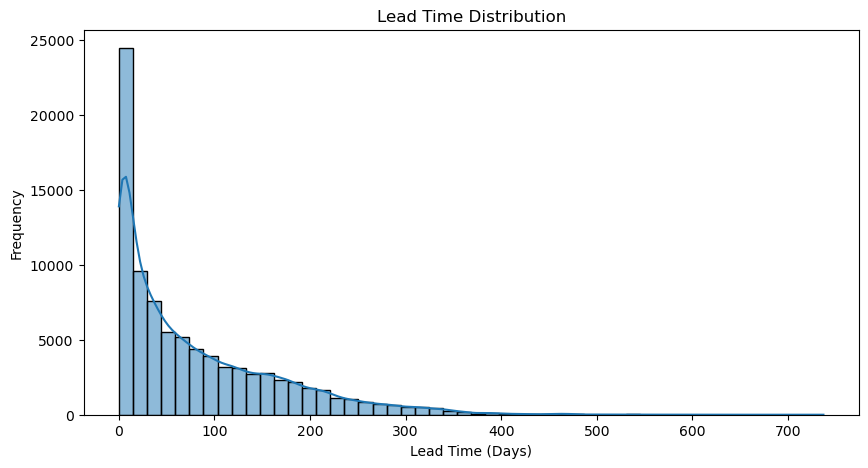

In [5]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['lead_time'],
    bins=50,
    kde=True
)

plt.title("Lead Time Distribution")
plt.xlabel("Lead Time (Days)")
plt.ylabel("Frequency")

plt.show()

## Lead Time Distribution

The histogram helps identify booking patterns and the spread of reservation lead times.

In [6]:
lead_cancel = df.groupby('is_canceled')['lead_time'].mean()

lead_cancel

is_canceled
0     70.126989
1    105.720018
Name: lead_time, dtype: float64

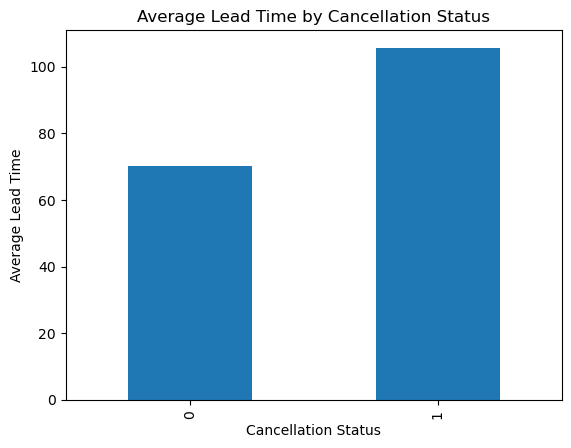

In [7]:
lead_cancel.plot(
    kind='bar'
)

plt.title("Average Lead Time by Cancellation Status")
plt.xlabel("Cancellation Status")
plt.ylabel("Average Lead Time")

plt.show()

In [8]:
df['lead_group'] = pd.cut(
    df['lead_time'],
    bins=[0,30,90,180,800],
    labels=[
        'Short',
        'Medium',
        'Long',
        'Very Long'
    ]
)

df['lead_group'].value_counts()

lead_group
Short        28647
Medium       22736
Long         18241
Very Long    11765
Name: count, dtype: int64

In [17]:
lead_cancel_rate = (
    df.groupby('lead_group', observed=False)['is_canceled']
      .mean()
      .mul(100)
      .round(2)
)

print(lead_cancel_rate)

lead_group
Short        18.62
Medium       32.02
Long         34.98
Very Long    39.74
Name: is_canceled, dtype: float64


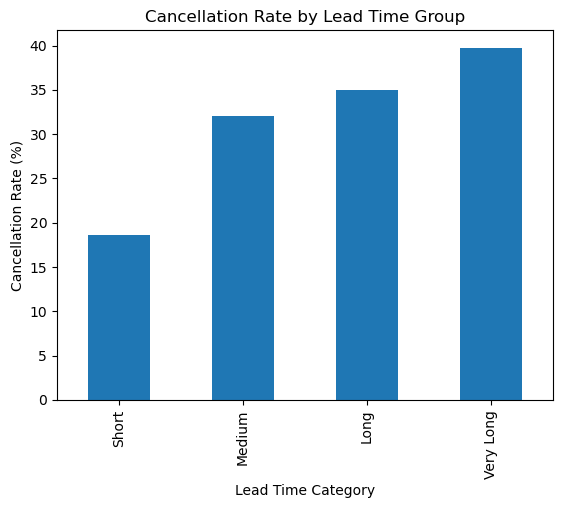

In [14]:
lead_cancel_rate.plot(
    kind='bar'
)

plt.title(
    "Cancellation Rate by Lead Time Group"
)

plt.xlabel(
    "Lead Time Category"
)

plt.ylabel(
    "Cancellation Rate (%)"
)

plt.show()

## Business Interpretation

Customers booking far in advance may have a higher likelihood of cancelling due to changing travel plans.

Lead time is an important variable for cancellation prediction and revenue forecasting.

## Findings

- Lead time distribution was analyzed.
- Average lead time was compared between cancelled and retained bookings.
- Lead times were grouped into booking categories.
- Cancellation rates were measured across lead-time groups.
- Longer booking horizons appear to influence cancellation behavior.

## Day 4 Conclusion

Lead time was found to have a noticeable relationship with booking cancellations.

Customers booking further in advance tend to show higher cancellation rates compared to last-minute bookings.

These insights can help hotels improve forecasting accuracy and cancellation management strategies.